<a href="https://colab.research.google.com/github/matiasmorgan1/Master-s-by-Research/blob/main/Multivariate_PLSR_Analysis_Seasonal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# PLSR with non-uniform lag times

In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

file_path = (
    "/content/drive/My Drive/Spreadsheets/MASTER_SPREADSHEET_SEASONAL.xlsx"
)

response_col = "Discharge Anomaly (Gt/yr)"
surface_var = "Surface temp Anomaly (°C)"
lags = [0, 1, 2, 3]
n_components = 3

# USER CONTROL
max_ocean_depth = 600  # metres (set to None to include all layers)

xls = pd.ExcelFile(file_path)
all_sheets = xls.sheet_names

# Define glacier pairs to merge: (Primary/Ocean source, Secondary, Combined Name)
pairs_to_merge = [
    ("284", "286", "284/286"),
    ("320", "323", "320/323"),
]

# Map sheets into a dict so we can easily combine them
glacier_dfs = {
    str(sheet): pd.read_excel(file_path, sheet_name=sheet)
    for sheet in all_sheets
}

# Combine specified glacier pairs
for primary, secondary, combined_name in pairs_to_merge:
    p_key = next((k for k in glacier_dfs if str(k) == primary), None)
    s_key = next((k for k in glacier_dfs if str(k) == secondary), None)

    if p_key and s_key:
        df_p = glacier_dfs[p_key].copy()
        df_s = glacier_dfs[s_key].copy()

        # 1. Sum Discharge Anomalies
        df_p[response_col] = df_p[response_col] + df_s[response_col]

        # 2. Mean Surface Temp Anomaly (Atmospheric data)
        df_p[surface_var] = (df_p[surface_var] + df_s[surface_var]) / 2.0

        # Store merged DataFrame under the combined name and delete raw components
        glacier_dfs[combined_name] = df_p
        del glacier_dfs[p_key]
        del glacier_dfs[s_key]

results = []

# Run PLSR loop over combined dataset
for glacier, df in glacier_dfs.items():
    df = df.copy()  # Prevents SettingWithCopyWarning

    # 1️⃣ Split surface temperature into seasonal columns
    df["DJF_" + surface_var] = df[surface_var].where(
        df["Season"] == "DJF", np.nan
    )
    df["MAM_" + surface_var] = df[surface_var].where(
        df["Season"] == "MAM", np.nan
    )
    df["JJA_" + surface_var] = df[surface_var].where(
        df["Season"] == "JJA", np.nan
    )
    df["SON_" + surface_var] = df[surface_var].where(
        df["Season"] == "SON", np.nan
    )

    seasonal_cols = [
        "DJF_" + surface_var,
        "MAM_" + surface_var,
        "JJA_" + surface_var,
        "SON_" + surface_var,
    ]

    for col in seasonal_cols:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")

    # 2️⃣ Detect ocean temperature columns
    ocean_cols = [c for c in df.columns if "Ocean Temp" in c]

    # Apply max depth filter
    if max_ocean_depth is not None:
        filtered_ocean_cols = []
        for col in ocean_cols:
            depths = re.findall(r"\d+", col)
            if len(depths) >= 2:
                upper_depth = int(depths[1])
                if upper_depth <= max_ocean_depth:
                    filtered_ocean_cols.append(col)
        ocean_cols = filtered_ocean_cols

    forcing_cols = seasonal_cols + ocean_cols

    # 3️⃣ Create lagged predictors
    lagged_df = pd.DataFrame(index=df.index)

    for col in forcing_cols:
        for lag in lags:
            lagged_df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # Drop rows created by lagging
    lagged_df = lagged_df.dropna()

    Y = df.loc[lagged_df.index, response_col].values.reshape(-1, 1)

    if len(lagged_df) < 6:
        continue

    # Standardize predictors
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(lagged_df.values)

    # Run PLSR
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_scaled, Y)

    # Performance Metrics
    r2 = pls.score(X_scaled, Y)
    Y_pred = pls.predict(X_scaled)
    rmse = np.sqrt(np.mean((Y - Y_pred) ** 2))

    # Normalized RMSE (Range-based)
    y_range = Y.max() - Y.min()
    nrmse_range = rmse / y_range if y_range != 0 else np.nan

    # ----------------------------------------------------
    # SIGN ALIGNMENT STEP (LC1)
    # ----------------------------------------------------
    lc1_weights = pls.x_weights_[:, 0].copy()

    # Calculate latent component score T1 = X * w1
    t1_score = X_scaled @ lc1_weights

    # Check correlation between latent score T1 and Y (Discharge Anomaly)
    corr = np.corrcoef(t1_score, Y.ravel())[0, 1]

    if corr < 0:
        lc1_weights = -lc1_weights
    # ----------------------------------------------------

    result = {
        "Glacier": glacier,
        "R2": r2,
        "RMSE": rmse,
        "NRMSE_range": nrmse_range,
    }

    for col, loading in zip(lagged_df.columns, lc1_weights):
        result[col] = loading

    results.append(result)

# Combine results
plsr_lagged_results = pd.DataFrame(results)
plsr_lagged_results = plsr_lagged_results.sort_values("Glacier")

print(plsr_lagged_results)

    Glacier        R2      RMSE  NRMSE_range  \
0       224  0.844908  0.279381     0.116402   
1       226  0.704594  0.433777     0.161785   
2       227  0.665322  1.006974     0.137285   
3       232  0.802064  0.084554     0.106419   
4       233  0.670341  0.119046     0.144827   
5       238  0.499492  0.084728     0.133633   
6       239  0.816848  0.433522     0.118060   
7       245  0.454771  0.089599     0.177245   
8       258  0.811119  0.233300     0.123313   
9       266  0.478846  0.077602     0.163635   
10      270  0.612413  0.148709     0.123939   
11      281  0.776299  0.272066     0.132473   
23  284/286  0.661443  0.154367     0.132195   
12      293  0.658519  0.294726     0.166384   
13      296  0.456494  0.073383     0.171453   
14      297  0.267362  0.078610     0.202437   
15      298  0.380976  0.146603     0.180264   
16      300  0.798009  0.091329     0.127281   
17      302  0.462759  0.237715     0.231950   
18      303  0.523206  0.124472     0.20

K-MEANS

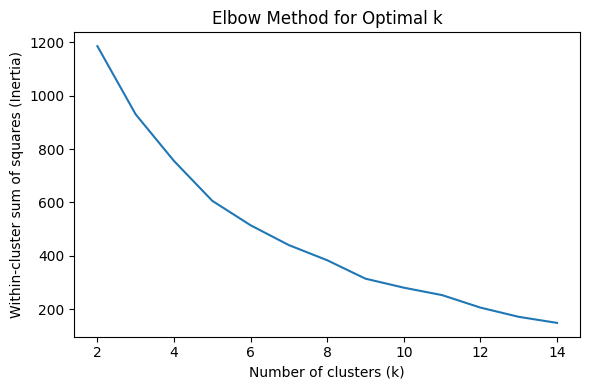

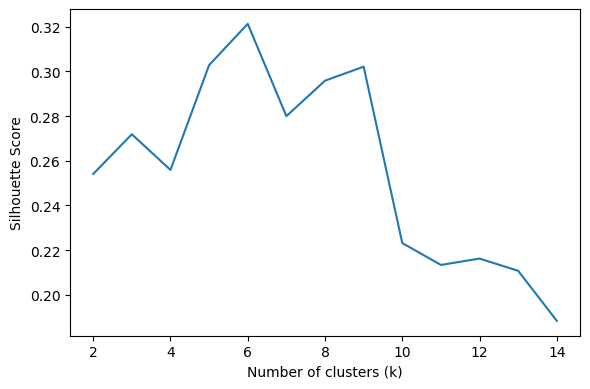

In [ ]:
# ==========================================
# Determine optimal number of clusters
# Elbow Method + Silhouette Score
# ==========================================

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Toggle: ignore negative loadings for clustering
positive_only_clustering = False

# Updated exclude list to remove all non-loading performance metrics
exclude_cols = ["Glacier", "Fjord Depth (m)", "R2", "RMSE", "NRMSE_range"]
loading_cols = [c for c in plsr_lagged_results.columns if c not in exclude_cols]

# Prepare clustering dataset
cluster_data = plsr_lagged_results.set_index("Glacier")[loading_cols]

if positive_only_clustering:
    cluster_data = cluster_data.clip(lower=0)

cluster_data = cluster_data.fillna(0)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(cluster_data)

# Range of cluster numbers to test
k_range = range(2, 15)

inertia = []
silhouette = []

for k in k_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

# -----------------------------
# Plot Elbow Method
# -----------------------------

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot Silhouette Score
# -----------------------------

plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette, marker='')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# KMeans Clustering – Assign glaciers to clusters
# ==========================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Toggle: ignore negative loadings for clustering only
positive_only_clustering = False

# Manually choose number of clusters
n_clusters = 6

# Updated exclude list to isolate ONLY driver loadings
exclude_cols = ["Glacier", "Fjord Depth (m)", "R2", "RMSE", "NRMSE_range"]
loading_cols = [c for c in plsr_lagged_results.columns if c not in exclude_cols]

# Data used for clustering
cluster_data = plsr_lagged_results.set_index("Glacier")[loading_cols]

# Optional: remove negative values
if positive_only_clustering:
    cluster_data = cluster_data.clip(lower=0)

# Fill NaNs
cluster_data = cluster_data.fillna(0)

# Standardize predictors
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# Run KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
clusters = kmeans.fit_predict(cluster_scaled)
clusters = clusters + 1

# Create results table
cluster_results = pd.DataFrame({
    "Glacier": cluster_data.index,
    "Cluster": clusters
})

# Sort by cluster
cluster_results = cluster_results.sort_values("Cluster")

print(cluster_results)

    Glacier  Cluster
3       232        1
7       245        1
14      296        1
9       266        1
12  284/286        1
13      293        1
20      304        1
17      300        1
24      335        1
21      310        1
19      303        2
22  320/323        2
18      302        2
23      330        2
11      281        2
8       258        2
16      298        3
15      297        3
4       233        4
0       224        4
2       227        5
1       226        5
5       238        6
6       239        6
10      270        6


In [ ]:
# ==============================================================================
# KMeans Clustering – Pairwise Cosine Similarity & RMSE Score Per Group
# ==============================================================================

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Toggle: ignore negative loadings for clustering only
positive_only_clustering = False

# Manually choose number of clusters
n_clusters = 6

# Filter loading columns
exclude_cols = [
    "Glacier",
    "Fjord Depth (m)",
    "R2",
    "RMSE",
    "NRMSE_range",
    "Cluster",
    "SillDepth",
]
loading_cols = [
    c
    for c in plsr_lagged_results.columns
    if c not in exclude_cols and "_lag" in c
]

# Data used for clustering
cluster_data = plsr_lagged_results.set_index("Glacier")[loading_cols]

# Optional: remove negative values
if positive_only_clustering:
    cluster_data = cluster_data.clip(lower=0)

# Fill NaNs
cluster_data = cluster_data.fillna(0)

# Standardize predictors for KMeans distance calculations
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# Run KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
clusters = kmeans.fit_predict(cluster_scaled) + 1  # 1-based cluster numbering

# Map glacier cluster assignments
cluster_results = pd.DataFrame(
    {"Glacier": cluster_data.index, "Cluster": clusters}
)

# ------------------------------------------------------------------------------
# Compute Pairwise Cosine Similarity & Cluster RMSE Per Group
# ------------------------------------------------------------------------------
group_scores = []

for cluster_id in sorted(cluster_results["Cluster"].unique()):
    # Get all glaciers in this cluster
    glaciers_in_cluster = cluster_results[
        cluster_results["Cluster"] == cluster_id
    ]["Glacier"]
    cluster_vectors = cluster_data.loc[glaciers_in_cluster].values
    n_glaciers = len(glaciers_in_cluster)

    # 1. Cosine Similarity Calculation
    if n_glaciers > 1:
        # Compute N x N pairwise similarity matrix
        sim_matrix = cosine_similarity(cluster_vectors)

        # Extract only off-diagonal unique pairs (upper triangle)
        triu_indices = np.triu_indices(n_glaciers, k=1)
        pairwise_sims = sim_matrix[triu_indices]

        # Calculate mean pairwise similarity for the group
        mean_pairwise_sim = np.mean(pairwise_sims)
    else:
        # Single-glacier clusters have no distinct pairs
        mean_pairwise_sim = 1.0

    # 2. RMSE Calculation (Distance from Cluster Centroid)
    centroid = np.mean(cluster_vectors, axis=0)

    if n_glaciers > 1:
        # Compute RMSE for each glacier relative to the centroid
        glacier_rmses = np.sqrt(np.mean((cluster_vectors - centroid) ** 2, axis=1))
        mean_rmse = np.mean(glacier_rmses)
    else:
        # Single-glacier clusters have 0 distance to their own centroid
        mean_rmse = 0.0

    group_scores.append(
        {
            "Cluster": cluster_id,
            "Glacier_Count": n_glaciers,
            "Pairwise_Cosine_Similarity": mean_pairwise_sim,
            "Cluster_RMSE": mean_rmse,
        }
    )

# Build group summary table
group_summary = pd.DataFrame(group_scores)

# ------------------------------------------------------------------------------
# Print Output
# ------------------------------------------------------------------------------
print("=== PER-GROUP PAIRWISE COSINE SIMILARITY & RMSE ===")
print(group_summary.to_string(index=False))

=== PER-GROUP PAIRWISE COSINE SIMILARITY & RMSE ===
 Cluster  Glacier_Count  Pairwise_Cosine_Similarity  Cluster_RMSE
       1             10                    0.751207      0.055940
       2              6                    0.541316      0.074943
       3              2                    0.855189      0.033635
       4              2                    0.776813      0.041757
       5              2                    0.838838      0.035484
       6              3                    0.322175      0.083879


Figure creation using LC1 from PLSR results for each glacier.

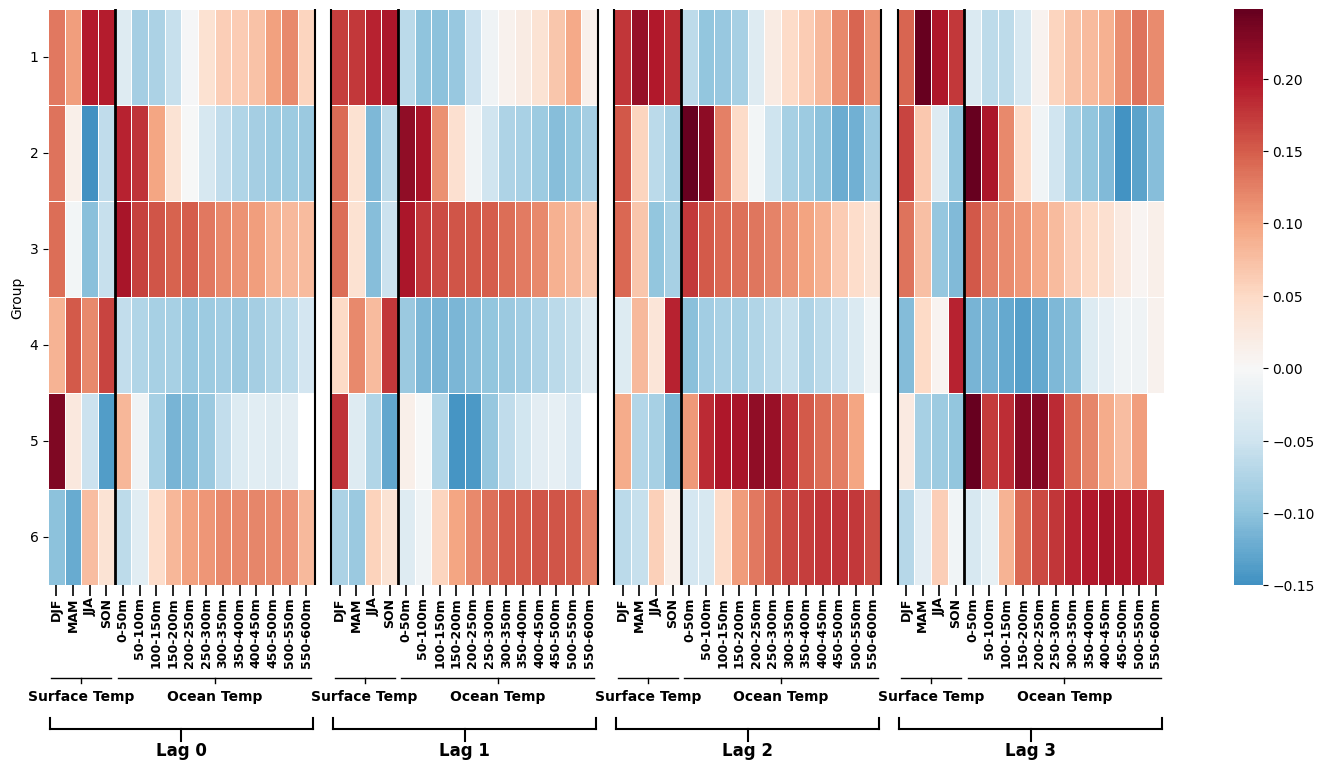

In [ ]:
# ==========================================
# Heatmap: Average Forcing Weights per Cluster (Final Formatting)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re

# ----------------------------
# 1. Identify ORIGINAL loading columns
# ----------------------------
exclude_cols = ["Glacier", "Fjord Depth (m)", "R2", "Cluster", "SillDepth", "_GAP_"]
original_cols = [c for c in clustered_data.columns if c not in exclude_cols]

# ----------------------------
# 2. Re-sorting Logic (Lag > Type > Season/Depth)
# ----------------------------
def get_hierarchy_sort_key(col):
    lag_match = re.search(r'lag(\d+)', col)
    lag_val = int(lag_match.group(1)) if lag_match else 99
    var_type = 0 if "Surface temp" in col else 1
    return (lag_val, var_type)

sorted_cols = sorted(original_cols, key=get_hierarchy_sort_key)

# ----------------------------
# 3. Compute means and Insert GAPs between Lags
# ----------------------------
cluster_means = clustered_data.groupby("Cluster")[sorted_cols].mean()

final_loading_cols = []
cluster_means_with_gaps = cluster_means.copy()

for i, col in enumerate(sorted_cols):
    final_loading_cols.append(col)
    if i < len(sorted_cols) - 1:
        curr_lag = re.search(r'lag(\d+)', col).group(1)
        next_lag = re.search(r'lag(\d+)', sorted_cols[i+1]).group(1)
        if curr_lag != next_lag:
            gap_name = f"_GAP_LAG_{curr_lag}_"
            cluster_means_with_gaps[gap_name] = np.nan
            final_loading_cols.append(gap_name)

heatmap_data = cluster_means_with_gaps[final_loading_cols]

# FIX: Force the cluster index to be exactly 1 to 5
heatmap_data.index = range(1, len(heatmap_data) + 1)

# ----------------------------
# Plot heatmap
# ----------------------------
fig, ax = plt.subplots(figsize=(18, 12))

sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar=True,
    ax=ax,
    xticklabels=False
)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ----------------------------
# Gap Boundaries & Internal Type Separators
# ----------------------------
n_cols = len(final_loading_cols)
gap_indices = [i for i, col in enumerate(final_loading_cols) if "_GAP_" in col]

# 1. Draw the physical Lag Gap boundaries
for g_idx in gap_indices:
    ax.axvline(g_idx, color='black', linewidth=1.5)
    ax.axvline(g_idx + 1, color='black', linewidth=1.5)

# 2. Draw black lines between Surface and Ocean Temp within each Lag
for i in range(n_cols - 1):
    col_curr = final_loading_cols[i]
    col_next = final_loading_cols[i+1]

    # Only draw if neither is a gap, and the variable type changes
    if "_GAP_" not in col_curr and "_GAP_" not in col_next:
        type_curr = "Surface" if "Surface temp" in col_curr else "Ocean"
        type_next = "Surface" if "Surface temp" in col_next else "Ocean"
        if type_curr != type_next:
            ax.axvline(i + 1, color='black', linewidth=2)

# ==========================================
# X-AXIS FORMATTING
# ==========================================

xticks = np.arange(len(final_loading_cols)) + 0.5
ax.set_xticks(xticks)
ax.tick_params(axis='x', which='major', length=8, width=1.2, direction='out', color='black')

for i, tick in enumerate(ax.xaxis.get_major_ticks()):
    if i < len(final_loading_cols) and "_GAP_" in final_loading_cols[i]:
        tick.tick1line.set_visible(False)

lag_start = 0
type_start = 0

for i, col in enumerate(final_loading_cols):
    if "_GAP_" in col:
        lag_start = i + 1
        type_start = i + 1
        continue

    # Metadata Parsing
    if "Surface temp" in col:
        var_type = "Surface Temp"
        detail = col.split("_")[0]
    else:
        var_type = "Ocean Temp"
        depth_match = re.search(r'(\d+-\d+m)', col)
        detail = depth_match.group(1) if depth_match else "Ocean"

    lag_label = f"Lag {re.search(r'lag(\d+)', col).group(1)}"

    # ROW 1: Season/Depth (Vertical labels)
    ax.text(i + 0.5, -0.02, detail, ha='center', va='top', rotation=90,
            transform=ax.get_xaxis_transform(), fontsize=9, fontweight='bold')

    is_last = (i == n_cols - 1)
    next_is_gap = (not is_last and "_GAP_" in final_loading_cols[i+1])

    if not is_last and not next_is_gap:
        next_col = final_loading_cols[i+1]
        next_type = "Surface Temp" if "Surface temp" in next_col else "Ocean Temp"
        next_lag = f"Lag {re.search(r'lag(\d+)', next_col).group(1)}"
    else:
        next_type, next_lag = None, None

    # ROW 2: Surface/Ocean Temp Brackets
    if is_last or next_is_gap or var_type != next_type:
        mid = (type_start + i + 1) / 2
        bracket_y2 = -0.16
        ax.plot([type_start + 0.2, i + 0.8], [bracket_y2, bracket_y2], color='black', lw=1, transform=ax.get_xaxis_transform(), clip_on=False)
        ax.plot([mid, mid], [bracket_y2, bracket_y2 - 0.01], color='black', lw=1, transform=ax.get_xaxis_transform(), clip_on=False)
        ax.text(mid, -0.18, var_type, ha='center', va='top', fontweight='bold', transform=ax.get_xaxis_transform(), fontsize=10)
        type_start = i + 1

    # ROW 3: Lag Brackets
    if is_last or next_is_gap or lag_label != next_lag:
        mid = (lag_start + i + 1) / 2
        bracket_y3 = -0.25
        ax.plot([lag_start + 0.1, i + 0.9], [bracket_y3, bracket_y3], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
        ax.plot([lag_start + 0.1, lag_start + 0.1], [bracket_y3, bracket_y3 + 0.02], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
        ax.plot([i + 0.9, i + 0.9], [bracket_y3, bracket_y3 + 0.02], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
        ax.plot([mid, mid], [bracket_y3, bracket_y3 - 0.02], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
        ax.text(mid, -0.27, lag_label, ha='center', va='top', fontsize=12, color='black', fontweight='bold', transform=ax.get_xaxis_transform())
        lag_start = i + 1

plt.subplots_adjust(bottom=0.4)
ax.set_ylabel("Group")
ax.set_title("", pad=20, fontsize=16)
plt.show()

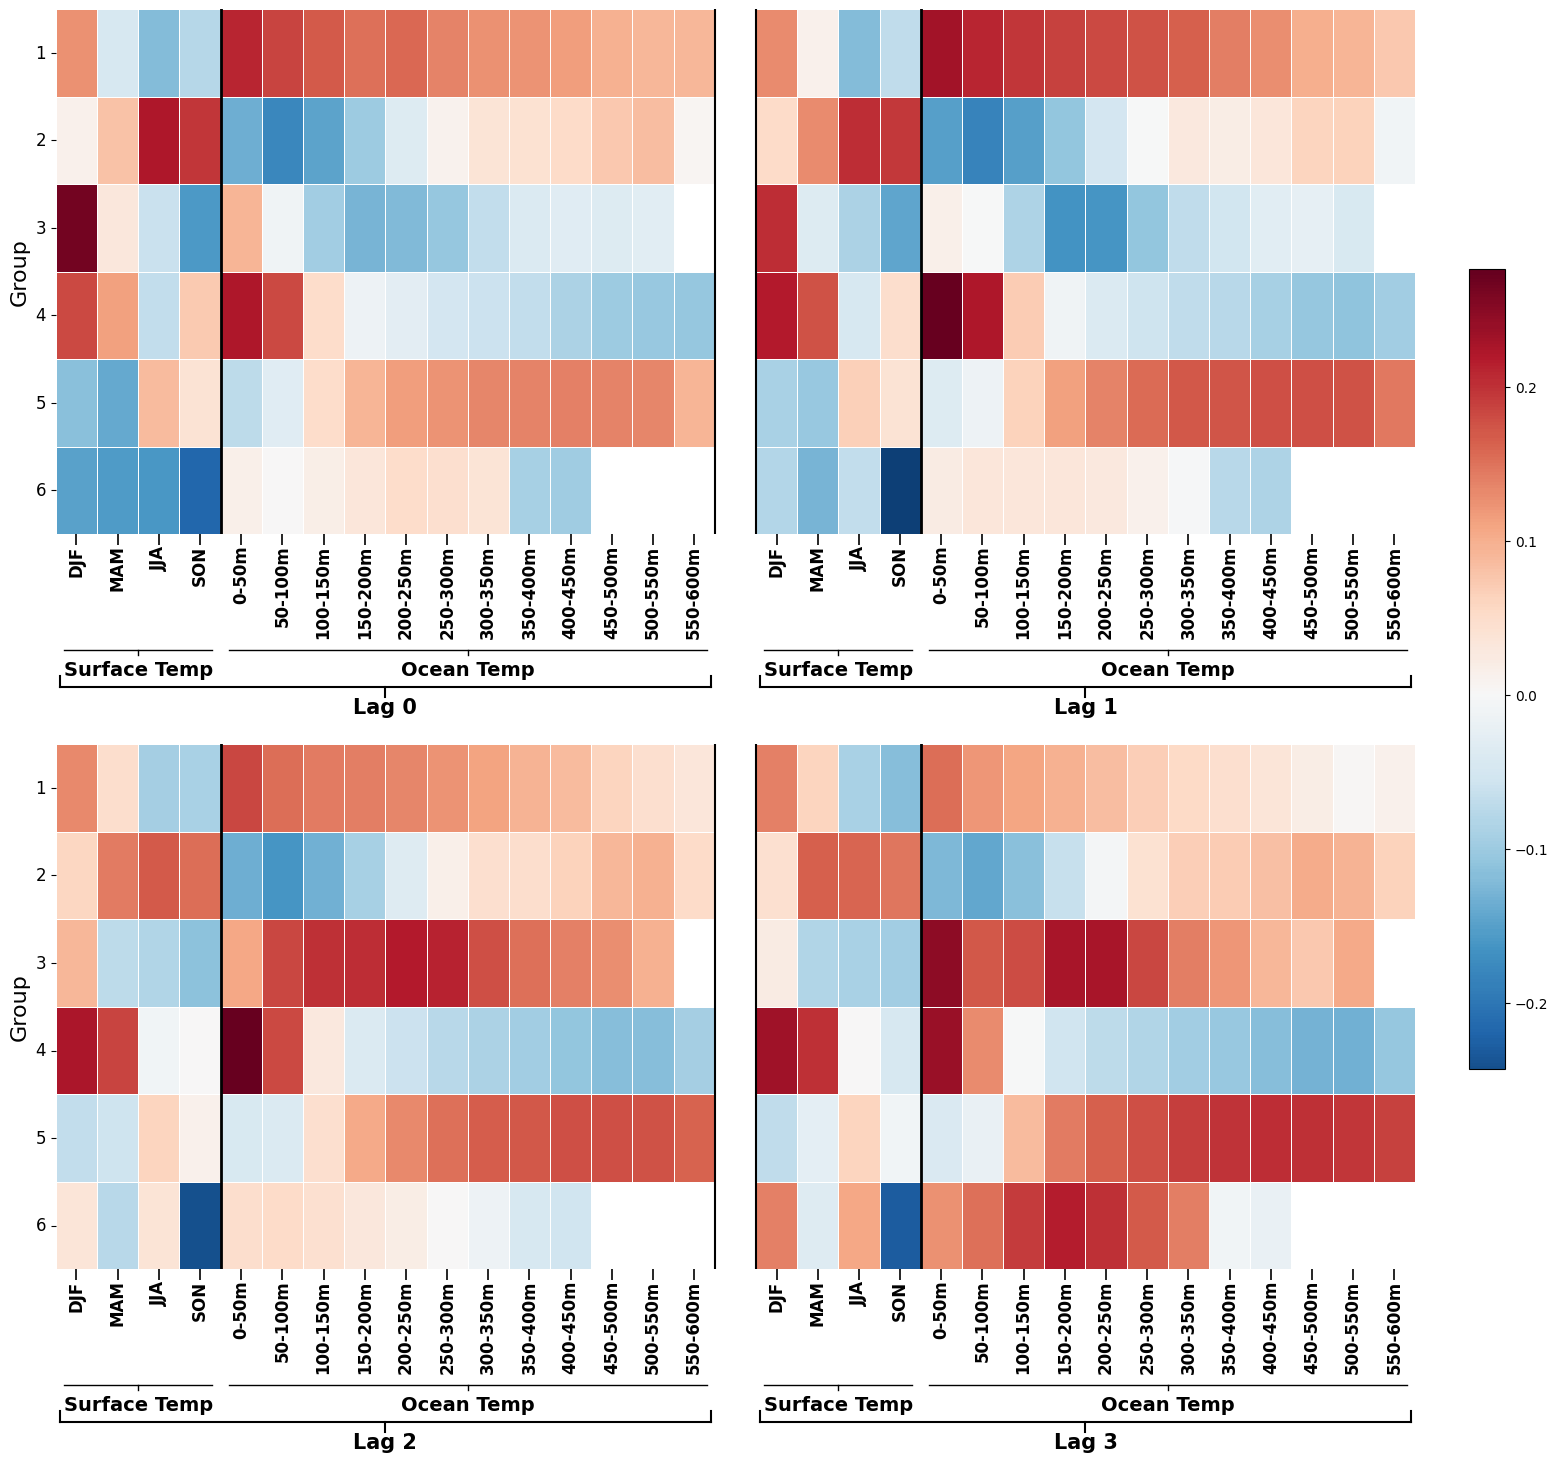

In [ ]:
# ==========================================
# Heatmap: Average Forcing Weights per Cluster (Final Formatting)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re

# ----------------------------
# 1. Identify ORIGINAL loading columns
# ----------------------------
exclude_cols = ["Glacier", "Fjord Depth (m)", "R2", "Cluster", "SillDepth", "_GAP_"]
original_cols = [c for c in clustered_data.columns if c not in exclude_cols]

# ----------------------------
# 2. Re-sorting Logic (Lag > Type > Season/Depth)
# ----------------------------
def get_hierarchy_sort_key(col):
    lag_match = re.search(r'lag(\d+)', col)
    lag_val = int(lag_match.group(1)) if lag_match else 99
    var_type = 0 if "Surface temp" in col else 1
    return (lag_val, var_type)

sorted_cols = sorted(original_cols, key=get_hierarchy_sort_key)

# ----------------------------
# 3. Compute means and Insert GAPs between Lags
# ----------------------------
cluster_means = clustered_data.groupby("Cluster")[sorted_cols].mean()

# === CREATE THE SUBPLOT FIGURE CONTROLLER ===
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(18, 20))

figs_to_generate = [
    {"target_lags": [0, 1], "ax": ax_top},
    {"target_lags": [2, 3], "ax": ax_bottom}
]

# Track the heatmap object to generate a single common colorbar later
last_heatmap = None

for fig_config in figs_to_generate:
    target_lags = fig_config["target_lags"]
    ax = fig_config["ax"]

    # Filter columns that belong to the current figure's lags
    current_sorted_cols = []
    for col in sorted_cols:
        lag_match = re.search(r'lag(\d+)', col)
        if lag_match and int(lag_match.group(1)) in target_lags:
            current_sorted_cols.append(col)

    if not current_sorted_cols:
        continue

    final_loading_cols = []
    cluster_means_with_gaps = cluster_means.copy()

    for i, col in enumerate(current_sorted_cols):
        final_loading_cols.append(col)
        if i < len(current_sorted_cols) - 1:
            curr_lag = re.search(r'lag(\d+)', col).group(1)
            next_lag = re.search(r'lag(\d+)', current_sorted_cols[i+1]).group(1)
            if curr_lag != next_lag:
                gap_name = f"_GAP_LAG_{curr_lag}_"
                cluster_means_with_gaps[gap_name] = np.nan
                final_loading_cols.append(gap_name)

    heatmap_data = cluster_means_with_gaps[final_loading_cols]

    # FIX: Force the cluster index to be exactly 1 to 5
    heatmap_data.index = range(1, len(heatmap_data) + 1)

    # ----------------------------
    # Plot heatmap (cbar=False hides individual legends)
    # ----------------------------
    last_heatmap = sns.heatmap(
        heatmap_data,
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        cbar=False,
        ax=ax,
        xticklabels=False
    )

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

    # ----------------------------
    # Gap Boundaries & Internal Type Separators
    # ----------------------------
    n_cols = len(final_loading_cols)
    gap_indices = [i for i, col in enumerate(final_loading_cols) if "_GAP_" in col]

    # 1. Draw the physical Lag Gap boundaries
    for g_idx in gap_indices:
        ax.axvline(g_idx, color='black', linewidth=1.5)
        ax.axvline(g_idx + 1, color='black', linewidth=1.5)

    # 2. Draw black lines between Surface and Ocean Temp within each Lag
    for i in range(n_cols - 1):
        col_curr = final_loading_cols[i]
        col_next = final_loading_cols[i+1]

        # Only draw if neither is a gap, and the variable type changes
        if "_GAP_" not in col_curr and "_GAP_" not in col_next:
            type_curr = "Surface" if "Surface temp" in col_curr else "Ocean"
            type_next = "Surface" if "Surface temp" in col_next else "Ocean"
            if type_curr != type_next:
                ax.axvline(i + 1, color='black', linewidth=2)

    # ==========================================
    # X-AXIS FORMATTING
    # ==========================================

    xticks = np.arange(len(final_loading_cols)) + 0.5
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', which='major', length=8, width=1.2, direction='out', color='black')

    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        if i < len(final_loading_cols) and "_GAP_" in final_loading_cols[i]:
            tick.tick1line.set_visible(False)

    lag_start = 0
    type_start = 0

    for i, col in enumerate(final_loading_cols):
        if "_GAP_" in col:
            lag_start = i + 1
            type_start = i + 1
            continue

        # Metadata Parsing
        if "Surface temp" in col:
            var_type = "Surface Temp"
            detail = col.split("_")[0]
        else:
            var_type = "Ocean Temp"
            depth_match = re.search(r'(\d+-\d+m)', col)
            detail = depth_match.group(1) if depth_match else "Ocean"

        lag_label = f"Lag {re.search(r'lag(\d+)', col).group(1)}"

        # ROW 1: Season/Depth (Vertical labels)
        ax.text(i + 0.5, -0.02, detail, ha='center', va='top', rotation=90,
                transform=ax.get_xaxis_transform(), fontsize=12, fontweight='bold')

        is_last = (i == n_cols - 1)
        next_is_gap = (not is_last and "_GAP_" in final_loading_cols[i+1])

        if not is_last and not next_is_gap:
            next_col = final_loading_cols[i+1]
            next_type = "Surface Temp" if "Surface temp" in next_col else "Ocean Temp"
            next_lag = f"Lag {re.search(r'lag(\d+)', next_col).group(1)}"
        else:
            next_type, next_lag = None, None

        # ROW 2: Surface/Ocean Temp Brackets
        if is_last or next_is_gap or var_type != next_type:
            mid = (type_start + i + 1) / 2
            bracket_y2 = -0.22
            ax.plot([type_start + 0.2, i + 0.8], [bracket_y2, bracket_y2], color='black', lw=1, transform=ax.get_xaxis_transform(), clip_on=False)
            ax.plot([mid, mid], [bracket_y2, bracket_y2 - 0.01], color='black', lw=1, transform=ax.get_xaxis_transform(), clip_on=False)
            ax.text(mid, -0.24, var_type, ha='center', va='top', fontweight='bold', transform=ax.get_xaxis_transform(), fontsize=14)
            type_start = i + 1

        # ROW 3: Lag Brackets
        if is_last or next_is_gap or lag_label != next_lag:
            mid = (lag_start + i + 1) / 2
            bracket_y3 = -0.29
            ax.plot([lag_start + 0.1, i + 0.9], [bracket_y3, bracket_y3], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
            ax.plot([lag_start + 0.1, lag_start + 0.1], [bracket_y3, bracket_y3 + 0.02], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
            ax.plot([i + 0.9, i + 0.9], [bracket_y3, bracket_y3 + 0.02], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
            ax.plot([mid, mid], [bracket_y3, bracket_y3 - 0.02], color='black', lw=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
            ax.text(mid, -0.31, lag_label, ha='center', va='top', fontsize=15, color='black', fontweight='bold', transform=ax.get_xaxis_transform())
            lag_start = i + 1

    ax.set_ylabel("Group", fontsize=16)
    ax.set_title("", pad=20, fontsize=20)

# Adjust layouts and leave room on the right side (right=0.88) for the single colorbar legend
plt.subplots_adjust(bottom=0.25, hspace=0.4, right=0.88)

# Add a single colorbar shared across the subplots
cbar_ax = fig.add_axes([0.91, 0.35, 0.02, 0.4])
fig.colorbar(last_heatmap.get_children()[0], cax=cbar_ax)

plt.show()

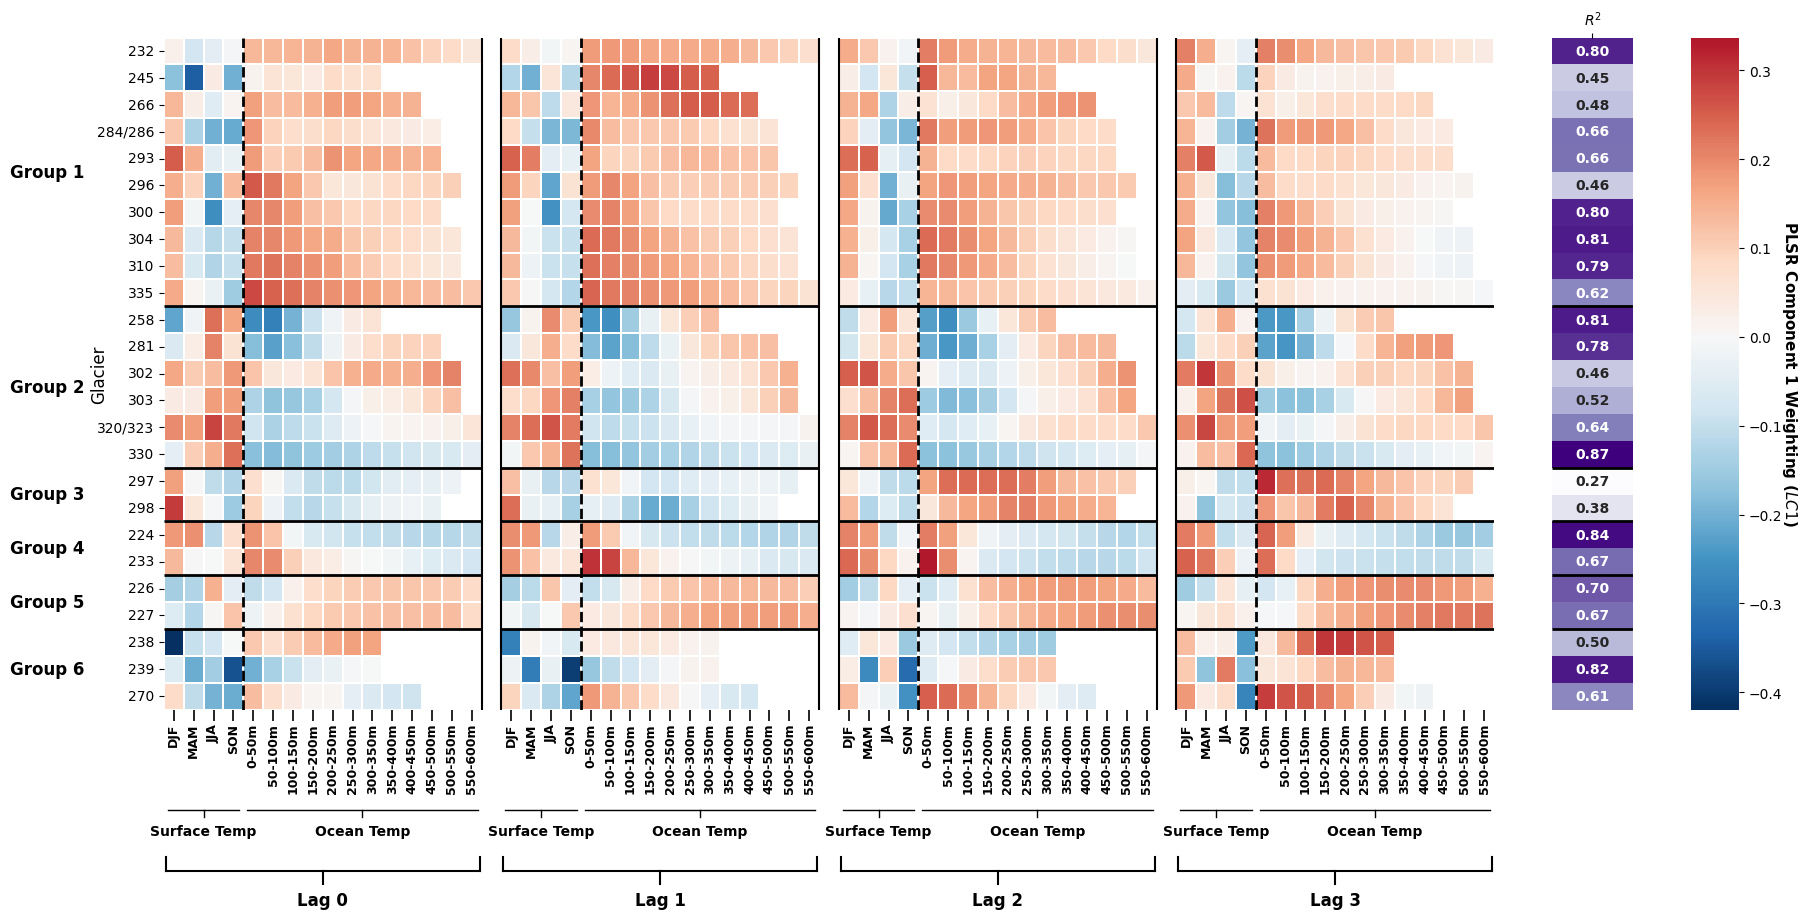

In [ ]:
# ==============================================================================
# Heatmap: Individual Glaciers with Hierarchy (Season > Type > Lag) & R2 Values
# ==============================================================================

import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Helper function to safely extract lag number from a column name
def get_lag_num(col_name):
    match = re.search(r"lag(\d+)", str(col_name))
    return int(match.group(1)) if match else 99


# Helper function to extract leading integer for glacier sorting
def get_glacier_num(name):
    match = re.search(r"\d+", str(name))
    return int(match.group()) if match else float("inf")


# ----------------------------
# 1. Setup Data, Cluster Merging & Numerical Glacier Sorting
# ----------------------------
clustered_data = plsr_lagged_results.merge(cluster_results, on="Glacier")
clustered_data["Cluster"] = clustered_data["Cluster"] + 1

# Sort by Cluster first, then by Glacier number ascending
clustered_data["Glacier_Sort_Key"] = clustered_data["Glacier"].apply(
    get_glacier_num
)
clustered_data_sorted = clustered_data.sort_values(
    by=["Cluster", "Glacier_Sort_Key"], ascending=[True, True]
).drop(columns=["Glacier_Sort_Key"])

# Extract R2 array matching the sorted index
r2_series = clustered_data_sorted.set_index("Glacier")["R2"]

# ----------------------------
# 2. Re-sorting Logic (Lag > Type > Season/Depth)
# ----------------------------
exclude_cols = [
    "Glacier",
    "Fjord Depth (m)",
    "R2",
    "Cluster",
    "SillDepth",
    "_GAP_",
    "Glacier_Sort_Key",
]
# Ensure we only pick predictor columns that contain lag information
original_cols = [
    c
    for c in clustered_data.columns
    if c not in exclude_cols and "lag" in c.lower()
]


def get_hierarchy_sort_key(col):
    lag_val = get_lag_num(col)
    var_type = 0 if "Surface temp" in col else 1
    return (lag_val, var_type)


sorted_cols = sorted(original_cols, key=get_hierarchy_sort_key)

# ----------------------------
# 3. Insert GAPs between Lags
# ----------------------------
final_loading_cols = []
clustered_data_with_gaps = clustered_data_sorted.copy()

for i, col in enumerate(sorted_cols):
    final_loading_cols.append(col)
    if i < len(sorted_cols) - 1:
        curr_lag = get_lag_num(col)
        next_lag = get_lag_num(sorted_cols[i + 1])
        if curr_lag != next_lag and curr_lag != 99:
            gap_name = f"_GAP_LAG_{curr_lag}_"
            clustered_data_with_gaps[gap_name] = np.nan
            final_loading_cols.append(gap_name)

heatmap_data = clustered_data_with_gaps.set_index("Glacier")[
    final_loading_cols
]

# Track cluster sizes for Y-axis bracket logic
cluster_sizes = clustered_data_with_gaps.groupby("Cluster", sort=False).size()
cluster_boundaries = np.cumsum(cluster_sizes.values)

# ----------------------------
# 4. Multi-Axis Subplot Framework
# ----------------------------
fig, (ax_main, ax_r2, ax_cbar) = plt.subplots(
    1,
    3,
    figsize=(21, 14),
    gridspec_kw={"width_ratios": [83, 5, 3], "wspace": 0.12},
)

# ----------------------------
# 5. Plot Heatmap (Main Axis) & Label Colorbar
# ----------------------------
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    cbar=True,
    cbar_ax=ax_cbar,
    ax=ax_main,
    xticklabels=False,
)

ax_main.set_yticklabels(ax_main.get_yticklabels(), rotation=0)

# Add label to the colorbar axis
ax_cbar.set_ylabel(
    "PLSR Component 1 Weighting ($LC1$)",
    fontsize=11,
    fontweight="bold",
    labelpad=12,
    rotation=270,
)

# ----------------------------
# 6. Plot R2 Column (Middle Axis)
# ----------------------------
r2_matrix = r2_series.values.reshape(-1, 1)
sns.heatmap(
    r2_matrix,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    cbar=False,
    ax=ax_r2,
    xticklabels=["$R^2$"],
    yticklabels=False,
    annot_kws={"weight": "bold", "size": 10},
)
ax_r2.set_ylabel("")
ax_r2.tick_params(
    axis="x", which="both", bottom=False, top=False, labelbottom=True
)
ax_r2.xaxis.tick_top()

# ----------------------------
# 7. Boundaries & Internal Separators (Main Axis)
# ----------------------------
n_cols = len(final_loading_cols)
gap_indices = [
    i for i, col in enumerate(final_loading_cols) if "_GAP_" in col
]

# Physical Lag Gaps
for g_idx in gap_indices:
    ax_main.axvline(g_idx, color="black", linewidth=1.5)
    ax_main.axvline(g_idx + 1, color="black", linewidth=1.5)

# Cluster Separators
for boundary in cluster_boundaries[:-1]:
    start = 0
    for g_idx in gap_indices:
        ax_main.hlines(boundary, start, g_idx, colors="black", linewidth=2)
        start = g_idx + 1
    ax_main.hlines(boundary, start, n_cols, colors="black", linewidth=2)
    ax_r2.hlines(boundary, 0, 1, colors="black", linewidth=2)

# Internal Type Separators (Vertical - Surface vs Ocean)
for i in range(n_cols - 1):
    col_curr = final_loading_cols[i]
    col_next = final_loading_cols[i + 1]
    if "_GAP_" not in col_curr and "_GAP_" not in col_next:
        type_curr = "Surface" if "Surface temp" in col_curr else "Ocean"
        type_next = "Surface" if "Surface temp" in col_next else "Ocean"
        if type_curr != type_next:
            ax_main.axvline(i + 1, color="black", ls="--", linewidth=2)

# ----------------------------
# 8. Cluster Brackets (Y-axis)
# ----------------------------
x_bracket = -0.5
start = 0
for i, size in enumerate(cluster_sizes):
    end = start + size
    ax_main.text(
        x_bracket - 3.5,
        (start + end) / 2,
        f"Group {i+1}",
        va="center",
        ha="right",
        fontsize=12,
        fontweight="bold",
    )
    start = end

# ----------------------------
# 9. X-Axis Formatting (Hierarchy)
# ----------------------------
xticks = np.arange(len(final_loading_cols)) + 0.5
ax_main.set_xticks(xticks)
ax_main.tick_params(
    axis="x",
    which="major",
    length=8,
    width=1.2,
    direction="out",
    color="black",
)

for i, tick in enumerate(ax_main.xaxis.get_major_ticks()):
    if i < len(final_loading_cols) and "_GAP_" in final_loading_cols[i]:
        tick.tick1line.set_visible(False)

lag_start, type_start = 0, 0
for i, col in enumerate(final_loading_cols):
    if "_GAP_" in col:
        lag_start, type_start = i + 1, i + 1
        continue

    var_type = "Surface Temp" if "Surface temp" in col else "Ocean Temp"
    detail = (
        col.split("_")[0]
        if "Surface temp" in col
        else (
            re.search(r"(\d+-\d+m)", col).group(1)
            if re.search(r"(\d+-\d+m)", col)
            else "Ocean"
        )
    )
    lag_val = get_lag_num(col)
    lag_label = f"Lag {lag_val}"

    # ROW 1: Season/Depth
    ax_main.text(
        i + 0.5,
        -0.02,
        detail,
        ha="center",
        va="top",
        rotation=90,
        transform=ax_main.get_xaxis_transform(),
        fontsize=9,
        fontweight="bold",
    )

    is_last = i == n_cols - 1
    next_is_gap = not is_last and "_GAP_" in final_loading_cols[i + 1]

    if not is_last and not next_is_gap:
        next_col = final_loading_cols[i + 1]
        next_type = (
            "Surface Temp" if "Surface temp" in next_col else "Ocean Temp"
        )
        next_lag = f"Lag {get_lag_num(next_col)}"
    else:
        next_type, next_lag = None, None

    # ROW 2: Surface/Ocean Temp Brackets
    if is_last or next_is_gap or var_type != next_type:
        mid = (type_start + i + 1) / 2
        bracket_y2 = -0.15
        ax_main.plot(
            [type_start + 0.2, i + 0.8],
            [bracket_y2, bracket_y2],
            color="black",
            lw=1,
            transform=ax_main.get_xaxis_transform(),
            clip_on=False,
        )
        ax_main.plot(
            [mid, mid],
            [bracket_y2, bracket_y2 - 0.01],
            color="black",
            lw=1,
            transform=ax_main.get_xaxis_transform(),
            clip_on=False,
        )
        ax_main.text(
            mid,
            -0.17,
            var_type,
            ha="center",
            va="top",
            fontweight="bold",
            transform=ax_main.get_xaxis_transform(),
            fontsize=10,
        )
        type_start = i + 1

    # ROW 3: Lag Brackets
    if is_last or next_is_gap or lag_label != next_lag:
        mid = (lag_start + i + 1) / 2
        bracket_y3 = -0.24
        ax_main.plot(
            [lag_start + 0.1, i + 0.9],
            [bracket_y3, bracket_y3],
            color="black",
            lw=1.5,
            transform=ax_main.get_xaxis_transform(),
            clip_on=False,
        )
        ax_main.plot(
            [lag_start + 0.1, lag_start + 0.1],
            [bracket_y3, bracket_y3 + 0.02],
            color="black",
            lw=1.5,
            transform=ax_main.get_xaxis_transform(),
            clip_on=False,
        )
        ax_main.plot(
            [i + 0.9, i + 0.9],
            [bracket_y3, bracket_y3 + 0.02],
            color="black",
            lw=1.5,
            transform=ax_main.get_xaxis_transform(),
            clip_on=False,
        )
        ax_main.plot(
            [mid, mid],
            [bracket_y3, bracket_y3 - 0.02],
            color="black",
            lw=1.5,
            transform=ax_main.get_xaxis_transform(),
            clip_on=False,
        )
        ax_main.text(
            mid,
            -0.27,
            lag_label,
            ha="center",
            va="top",
            fontsize=12,
            color="black",
            fontweight="bold",
            transform=ax_main.get_xaxis_transform(),
        )
        lag_start = i + 1

# Final adjustments
plt.subplots_adjust(bottom=0.4, left=0.15)
ax_main.set_ylabel("Glacier", labelpad=-8, fontsize=12)
plt.show()